In [1]:
# hide
# all_tutorial
! [ -e /content ] && pip install -Uqq mrl-pypi  # upgrade mrl on colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 11.4 MB/s eta 0:00:00


# Tutorial - LSTM Language Models

>Training and using LSTM language models

## LSTM Language Models

LSTM language models are a type of autoregressive generative model. This particular type of model is a good fit for RL-based optimization as they are light, robust and easy to optimize. These models make use of the [LSTM](https://arxiv.org/abs/1402.1128) architecture design.

Language models are trained in a self-supervised fashion by next token prediction. Given a series of tokens, the model predicts a probability distribution over he next token. Self supervised training is very fast and doesn't require any data labels. Each text string in the dataset labels itself.

During generation, we sample from the model in an autoregression fashion. Given an input token, the model predicts aa distribution of tokens over the next token. We then sample from that distributiona and feed the selected token back into the model. We repeat this process until either an end of sentence (EOS) token is predicted, or the generated sequence reaches a maximum allowed length.

During sampling, we save the log probability of each token predicted. This gives us a probability value for the model's estimated likelihood of the generated compound. We can also backprop through this value.

## Performance Notes

If running on Collab, remember to change the runtime to GPU

In [2]:
import sys
sys.path.append('..')

from mrl.imports import *
from mrl.core import *
from mrl.chem import *
from mrl.torch_imports import *
from mrl.torch_core import *
from mrl.layers import *
from mrl.dataloaders import *
from mrl.g_models.all import *
from mrl.train.agent import *
from mrl.vocab import *

## Setup

Before creating a model, we need to set up our data.

Our raw data is in the form of SMILES strings. We need to convert these to tensors.

First we need a `Vocab` to handle converting strings to tokens and mapping those tokens to integers. We will use the `CharacterVocab` class with the `SMILES_CHAR_VOCAB` vocabulary. This will tokenize SMILES on a character basis.

More sophisticated tokenization schemes exist, but character tokenization is nice for the simplicity. Character tokenization has a small, compact vocabulary. Other tokenization strategies can tokenize by more meaningful subwords, but these strategies create a long tail of low frequency tokens and lots of `unk` characters.

In [4]:
# if in the repo
df = pd.read_excel('/content/dataset.xlsx')

# if in Collab:
# download_files()
# df = pd.read_csv('files/smiles.csv')

In [5]:
df.head()

,smiles
0,s1ncc2c3c(n(OC)c12)cccc3
1,s1nc2cc(ccc2n1)C(=O)NC(=S)Nc1ccc(cc1)C(C)C
2,s1nc(C=2C[NH+](CCC=2)C)c(SCCCF)n1
3,s1cc(nc1C(C#N)=CNc1ccc(F)cc1F)-c1ccc(OC)cc1
4,s1c[n+](Cc2cnc(nc2N)C)c(C)c1CCO


In [6]:
vocab = CharacterVocab(SMILES_CHAR_VOCAB)

`vocab` first tokenizes smiles into characters, then numericalizes the tokens into integer keys

In [7]:
' '.join(vocab.tokenize(df.smiles.values[0]))

'bos s 1 n c c 2 c 3 c ( n ( O C ) c 1 2 ) c c c c 3 eos'

In [8]:
' '.join([str(i) for i in vocab.numericalize(vocab.tokenize(df.smiles.values[0]))])

'0 40 11 37 34 34 12 34 13 34 5 37 5 28 23 6 34 11 12 6 34 34 34 34 13 1'

Now we need a dataset. We will use the `Text_Dataset` class

In [9]:
dataset = Text_Dataset(df.smiles.values, vocab)
dataloader = dataset.dataloader(32)

Now we can look at the actual data

In [10]:
x,y = next(iter(dataloader))

In [11]:
x

tensor([[ 0, 40, 11,  ...,  2,  2,  2],
        [ 0, 40, 11,  ...,  2,  2,  2],
        [ 0, 40, 11,  ...,  2,  2,  2],
        ...,
        [ 0, 38, 11,  ...,  2,  2,  2],
        [ 0, 38, 11,  ...,  2,  2,  2],
        [ 0, 38, 11,  ...,  2,  2,  2]])

In [12]:
y

tensor([[40, 11, 37,  ...,  2,  2,  2],
        [40, 11, 37,  ...,  2,  2,  2],
        [40, 11, 37,  ...,  2,  2,  2],
        ...,
        [38, 11, 34,  ...,  2,  2,  2],
        [38, 11, 34,  ...,  2,  2,  2],
        [38, 11, 34,  ...,  2,  2,  2]])

You will notice the `y` tensor is the same as the `x` tensor with the values shifted by one. This is because the goal of autoregressive language modeling is to predict the next character given the previous series of characters.

## Model Creation

We can create a model through the `LSTM_LM` class

In [13]:
d_vocab = len(vocab.itos)
bos_idx = vocab.stoi['bos']
d_embedding = 256
d_hidden = 1024
n_layers = 3
bidir = False
tie_weights = True
input_dropout = 0.3
lstm_dropout = 0.3

model = LSTM_LM(d_vocab,
                d_embedding,
                d_hidden,
                n_layers,
                input_dropout,
                lstm_dropout,
                bos_idx,
                bidir,
                tie_weights)

We can see the model is quite simple. We have an embedding layer, three LSTM layers, and an output layer

In [14]:
model

LSTM_LM(
  (embedding): Embedding(47, 256)
  (lstm): LSTM(
    (input_drop): SequenceDropout()
    (lstm_drop): SequenceDropout()
    (lstms): ModuleList(
      (0): LSTM(256, 1024, batch_first=True)
      (1): LSTM(1024, 1024, batch_first=True)
      (2): LSTM(1024, 256, batch_first=True)
    )
  )
  (head): Linear(in_features=256, out_features=47, bias=True)
)

Now we'll put the model into a `GenerativeAgent` to manage supervised training.

We need to specify a loss function - we will use standard cross entropy

In [15]:
loss_function = CrossEntropy()

In [16]:
agent = GenerativeAgent(model, vocab, loss_function, dataset, base_model=False)

Now we can train in a supervised fashion on next token prediction

In [17]:
agent.train_supervised(32, 1, 1e-3)

Epoch,Train Loss,Valid Loss,Time
0,3.74535,3.56968,00:01


This was just a quick example to show the training API. We're not going to do a whole training process here. To train custom models, repeat this code with your own set of SMILES.

## Pre-trained Models

The MRL model zoo offers a number of pre-trained models. We'll load one of these to continue.

We'll use the `LSTM_LM_Small_Chembl` model. This model was trained first on a chunk of the ZINC database, then fine-tuned on the CHEMBL database

In [18]:
del model
del agent
gc.collect()
torch.cuda.empty_cache()

In [19]:
from mrl.model_zoo import LSTM_LM_Small_Chembl

In [20]:
agent = LSTM_LM_Small_Chembl(base_model=False)

Downloading: "https://dmai-mrl.s3.amazonaws.com/mrl_public/lstmlm_small_chembl.pt" to /root/.cache/torch/hub/checkpoints/lstmlm_small_chembl.pt
100%|██████████| 57.1M/57.1M [00:01<00:00, 35.3MB/s]


Now with a fully pre-trained model, we can look at drawing samples

In [21]:
preds, lps = agent.model.sample_no_grad(256, 100, temperature=1.)

In [22]:
preds

tensor([[23, 28, 34,  ...,  2,  2,  2],
        [23, 28, 23,  ...,  2,  2,  2],
        [23, 28, 23,  ...,  2,  2,  2],
        ...,
        [23, 27,  5,  ...,  2,  2,  2],
        [23, 34, 11,  ...,  2,  2,  2],
        [23, 23, 28,  ...,  2,  2,  2]], device='cuda:0')

In [23]:
lps.shape

torch.Size([256, 100])

The `sample_no_grad` function gives is two outputs - `preds` and `lps`.

`preds` is a long tensor of size `(bs, sl)` containing the integer tokens of the samples.

`lps` is a float tensor of size `(bs, sl)` containing the log probabilities of each value in `preds`

We can now reconstruct the predictions back into SMILES strings

In [24]:
smiles = agent.reconstruct(preds)

In [30]:
smiles[:100]

['COc1ccc(CCC2CCCCC2)c(OC)c1',
 'COC(=O)c1c(CCCCCCS(=O)(=O)NC(C)C)[nH]c2c1cc(Cl)c1ccccc12',
 'COCCN(C)C(=O)c1ccc(-c2cc3c(=O)n(C(C)C)c(=O)n(C)c3nc2OC)cc1',
 'CCNC(=O)c1cnc(Nc2ccccn2)cc1Nc1cccc2cnccc12',
 'COc1ccc(C2Sc3ccccc3N=C(S)N2C)cc1',
 'COc1cccc(NC(S)=NNC(=O)c2ccc(C)c([N+](=O)[O-])c2)c1',
 'CC(C)NC(=O)Nc1ccc(C(=O)c2ccccc2Cl)c(NS(=O)(=O)c2ccc(Cl)cc2)c1',
 'OC(CN1CCCCC1)Cn1cncn1',
 'Cc1ccc(C(=O)N/C(=C/c2cn(C)c3ccccc23)C(=O)NCC23CC4CC(CC(C4)C2)C3)cc1',
 'Cc1onc(-c2ccccc2Cl)c1C(=O)NC[C@H](NS(=O)(=O)n1ccc2ccccc21)C(=O)OCCO',
 'CCCc1c(-c2ccccc2)n(Cc2ccc(Cl)cc2)c(=O)n1CCC',
 'Cc1nc2ccccn2c1C(=O)N1CC(C)OC1(C)C',
 'CN(C)CCn1cc(NC(=O)c2cnn(-c3ccccc3)c(=O)c2N)cn1',
 'Cc1nc(N[C@@H]2CCOc3ccccc32)cc(-c2ccc(Cl)c(Cl)c2)n1',
 'CC(C)NC(=O)NC[C@@H]1Cc2ccccc2CN1C(=O)c1ccccc1-c1ccccc1C(=O)N(CCN(C)C)CCO',
 'O=C(O)c1[nH]c2cc(F)c(-c3cccs3)cc2c1CCC1=NCCN1',
 'COc1ccc2nc(NC(=O)CSc3n[nH]c(N)n3)sc2c1',
 'COc1nn(C)cc1-c1cnc(N)c(O[C@H](C)c2cc(F)ccc2-n2nccn2)c1',
 'CCNC(=O)[C@H](Cc1ccc(OS(=O)(=O)c2cccc3cnccc23)c

In [31]:
mols = to_mols(smiles)

Now lets look at some key generation statistics.

- diversity - the percentage of unique samples
- valid - the number of chemically valid samples

In [32]:
div = len(set(smiles))/len(smiles)
val = len([i for i in mols if i is not None])/len(mols)
print(f'Diversity:\t{div:.3f}\nValid:\t\t{val:.3f}')

Diversity:	1.000
Valid:		0.930


In [33]:
valid_mols = [i for i in mols if i is not None]

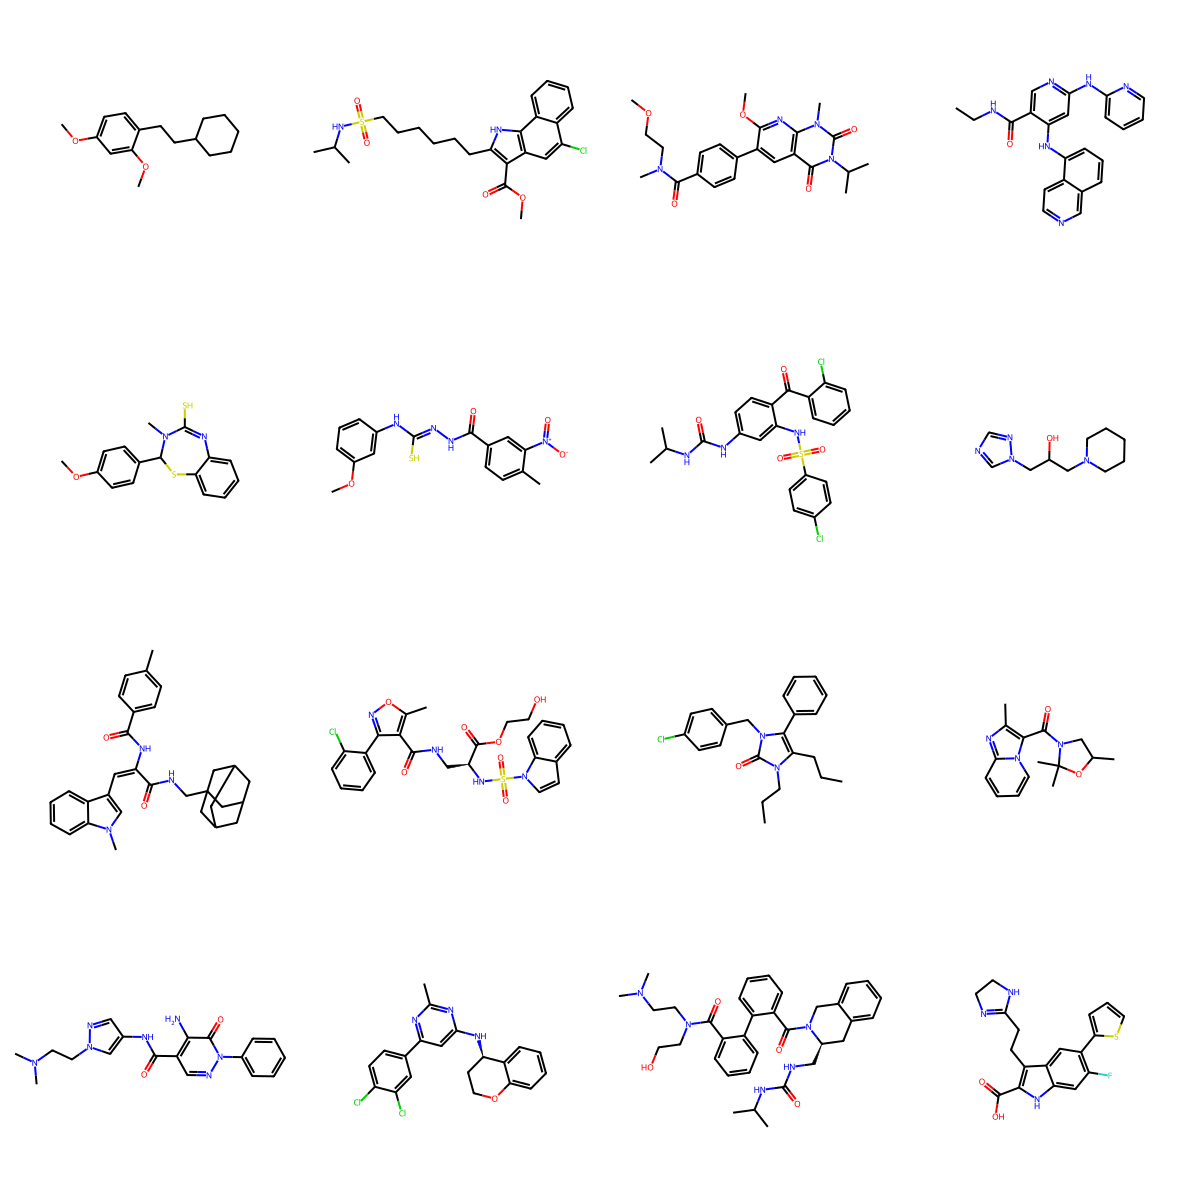

In [34]:
draw_mols(valid_mols[:16], mols_per_row=4)